In [1]:
using Clapeyron, Metaheuristics, Printf

In [2]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
water,18.02,1.2047,2.801457,353.94,1,1
propylamine,59.11,2.9773,3.2899,226.5,1,1
"""

unlike_parameter = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,propylamine,-0.01
"""

assoc_parameter = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
propylamine,H,propylamine,e,541.63,0.138988
water,H,water,e,2425.67,0.045
propylamine,H,water,e,1483.65,0.07883
propylamine,e,water,H,1483.65,0.07883
"""

model = PCSAFT(["water", "propylamine"], userlocations = [like_parameter, unlike_parameter, assoc_parameter])

println(model.params.epsilon.values)
println(model.params.sigma.values)
println("======================")
println("kij = ", (1  - ((model.params.epsilon.values[2])/(sqrt(model.params.epsilon.values[1] * model.params.epsilon.values[4])))))

[353.94 285.96988467494265; 285.96988467494265 226.5]
[2.8014570000000003e-10 3.0456785000000005e-10; 3.0456785000000005e-10 3.2899e-10]
kij = -0.010000000000000009


In [3]:
function vle_p(model::EoSModel, x_water::Float64)
    P = 101325 #ganti sesuai available data
    bub = bubble_temperature(model, P, [x_water , 1-x_water])
    T = bub[1]
    y = bub[4][1]
    return T
end

function vle_y(model::EoSModel, x_water::Float64)
    P = 101325 #ganti sesuai available data
    bub = bubble_temperature(model, P, [x_water , 1-x_water])
    p = bub[1]
    y = bub[4][1]
    return y
end

vle_y (generic function with 1 method)

In [5]:
toestimate = [
    Dict(
        :param   => :epsilon,
        :indices => (1,2),
        :lower   => 250.,
        :upper   => 350.0,
        :guess   => 285.
    )
]

1-element Vector{Dict{Symbol, Any}}:
 Dict(:upper => 350.0, :param => :epsilon, :indices => (1, 2), :guess => 285.0, :lower => 250.0)

In [6]:
# Run this ONCE to fix your CSV files
function fix_line_endings(filename)
    content = read(filename, String)
    fixed = replace(content, "\r\n" => "\n")
    write(filename, fixed)
    println("Fixed: $filename")
end

fix_line_endings("vlep_propylamine.csv")
fix_line_endings("vley_propylamine.csv")

estimator, objective, x0, upper, lower = Estimation(
    model,
    toestimate,
    [
        "vlep_propylamine.csv"
        "vley_propylamine.csv"
    ]
)
 
println("Initial objective value: ", objective(x0))

Fixed: vlep_propylamine.csv
Fixed: vley_propylamine.csv
Initial objective value: 0.6325487705857981


In [7]:
method = ECA(; options = Options(iterations = 1000000, seed = 42))
 
params_opt, model_opt = optimize(objective, estimator, method)

([316.8641457882513], PCSAFT{BasicIdeal, Float64}("water", "propylamine"))

In [8]:
println(model_opt.params.epsilon.values)
println(model_opt.params.sigma.values)
println("kij = ", (1  - ((model_opt.params.epsilon.values[2])/(sqrt(model_opt.params.epsilon.values[1] * model_opt.params.epsilon.values[4])))))

[353.94 316.8641457882513; 316.8641457882513 226.5]
[2.8014570000000003e-10 3.0456785000000005e-10; 3.0456785000000005e-10 3.2899e-10]
kij = -0.11911360040554575


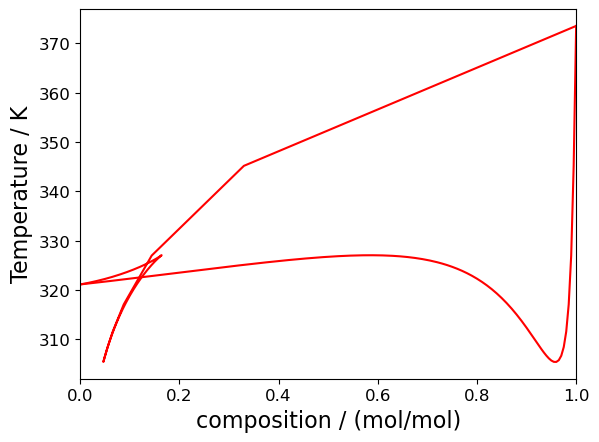

([300.0, 310.0, 320.0, 330.0, 340.0, 350.0, 360.0, 370.0, 380.0], PyCall.PyObject[PyObject Text(0, 300.0, '300'), PyObject Text(0, 310.0, '310'), PyObject Text(0, 320.0, '320'), PyObject Text(0, 330.0, '330'), PyObject Text(0, 340.0, '340'), PyObject Text(0, 350.0, '350'), PyObject Text(0, 360.0, '360'), PyObject Text(0, 370.0, '370'), PyObject Text(0, 380.0, '380')])

In [9]:
import PyPlot; const plt = PyPlot
using Clapeyron

N    = 201
p    = 101325

x    = LinRange(0., 1.,  N)
T    = zeros(N)
y    = zeros(N)

v0 = nothing
for i in 1:N
    if i==1
        bub = bubble_temperature(model, p, [x[i], 1-x[i]])
        T[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(bub[1],log10.([bub[2],bub[3]]),[x[i+1],1-x[i+1]])
    else
        bub = bubble_temperature(model, p, [x[i], 1-x[i]]; v0 = v0)
        T[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(bub[1],log10.([bub[2],bub[3]]),bub[4])
    end
end

plt.clf()
plt.plot(x, T, color="red")
plt.plot(y, T, color="red")
plt.xlabel("composition / (mol/mol)",fontsize=16)
plt.ylabel("Temperature / K",fontsize=16)
plt.xlim([0,1])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
     

In [10]:
using CSV, DataFrames, Printf

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [11]:
aard_p   = calculate_AAD(model_opt, "vlep_propylamine.csv", vle_p)


=== AAD: vlep_propylamine.csv ===

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



Clapeyron Estimator  exp           calc          ARD%    
0.1910      324.936500    325.123558    0.0576  
0.2480      326.336100    326.321036    0.0046  
0.3450      328.735400    328.459185    0.0840  
0.4380      332.434500    330.735598    0.5110  
0.5570      336.633700    334.272205    0.7015  
0.6350      340.232900    337.272351    0.8702  
0.7470      345.331400    343.400515    0.5591  
0.8160      348.230500    349.053218    0.2363  
AARD = 0.3780%


0.3780386162372537

In [12]:
aard_p   = calculate_AAD(model_opt, "vley_propylamine.csv", vle_y)


=== AAD: vley_propylamine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.1910      0.036000      0.039390      9.4155  
0.2480      0.050000      0.050274      0.5485  
0.3450      0.081000      0.069436      14.2760 
0.4380      0.112000      0.090009      19.6352 
0.5570      0.161000      0.123583      23.2404 
0.6350      0.204000      0.154658      24.1875 
0.7470      0.289000      0.228937      20.7830 
0.8160      0.349000      0.314398      9.9145  
AARD = 15.2501%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


15.2500879639508